In [1]:
import polars as pl

In [68]:
data = pl.read_parquet("S:/campaignfinance/data/processed/fec/individual_to_firm_pac_contributions/cycle_2022/individual_2022.parquet")

In [69]:
data.filter(pl.col("NAME") == "FORTUNE, STEVE")

CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,SOURCE_CYCLE
str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,i32
"""C00163832""","""N""","""30G""","""P""","""202212089550577919""","""15""","""IND""","""FORTUNE, STEVE""","""RICHMOND""","""TX""","""77406""","""CSX CORPORATION""","""EVP CHIEF DIGITAL & TECHNOLOGY…","""11012022""",416.0,null,"""A2022-2657575""","""1671002""",null,null,"""4011720231698375358""",2022
"""C00163832""","""N""","""YE""","""P""","""202301319576506497""","""15""","""IND""","""FORTUNE, STEVE""","""RICHMOND""","""TX""","""77406""","""CSX CORPORATION""","""EVP CHIEF DIGITAL & TECHNOLOGY…","""12012022""",416.0,null,"""A2022-2811941""","""1686382""",null,null,"""4020620231723068390""",2022


In [188]:
contrib_amount = data.drop_nulls(subset=["EMPLOYER", "NAME"]).group_by("NAME").agg(pl.col("TRANSACTION_AMT").sum())

In [193]:
contrib_amount.filter(pl.col("TRANSACTION_AMT") > 2000)

NAME,TRANSACTION_AMT
str,f64
"""FIRST, STEVEN A""",2228.0
"""CLINE, MICHAEL""",3944.0
"""OSETINSKY, VERONICA""",5000.0
"""GERO, RONALD M""",2826.0
"""RENJEL, LOUIS E.""",9097.0
…,…
"""O'DONNELL, STEPHEN""",2500.0
"""DUFFY, BRIANA""",9200.0
"""KOEHLER, MICHAEL R""",5824.0


In [163]:
master = data.filter(pl.col("CMTE_ID") == "C00303024")

In [175]:
master.filter(pl.col("NAME") == "AMBROSE, RICHARD F")

CMTE_ID,AMNDT_IND,RPT_TP,TRANSACTION_PGI,IMAGE_NUM,TRANSACTION_TP,ENTITY_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,OTHER_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,SOURCE_CYCLE
str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,i32
"""C00303024""","""N""","""M2""","""P""","""202102189428322431""","""15""","""IND""","""AMBROSE, RICHARD F""","""GREENWOOD VILLAGE""","""CO""","""801213935""","""LOCKHEED MARTIN""","""EVP SPACE""","""01312021""",400.0,null,"""PR368355875138""","""1500613""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4022620211189226218""",2022
"""C00303024""","""N""","""M3""","""P""","""202103169440544705""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP SPACE""","""02282021""",400.0,null,"""PR368355875425""","""1504297""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4031720211261395812""",2022
"""C00303024""","""N""","""M4""","""P""","""202104209443924196""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP SPACE""","""03312021""",400.0,null,"""PR368355875544""","""1513690""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4042520211279044424""",2022
"""C00303024""","""N""","""M5""","""P""","""202105209447074992""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP SPACE""","""04302021""",500.0,null,"""PR368355876130""","""1517533""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4052220211296939551""",2022
"""C00303024""","""N""","""M6""","""P""","""202106189449634630""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP SPACE""","""05312021""",400.0,null,"""PR368355876472""","""1520940""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4062320211309614798""",2022
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C00303024""","""N""","""M12""","""P""","""202112209474570850""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP SPACE""","""11302021""",400.0,null,"""PR368355878563""","""1552857""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4122220211386445912""",2022
"""C00303024""","""N""","""YE""","""P""","""202201319485631800""","""15""","""IND""","""AMBROSE, RICHARD F""","""LITTLETON""","""CO""","""801258504""","""LOCKHEED MARTIN""","""EVP & STRATEGIC ADVISOR""","""12312021""",300.0,null,"""PR368355879433""","""1564550""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4020820221405812061""",2022
"""C00303024""","""N""","""M2""","""P""","""202202179491765003""","""15""","""IND""","""AMBROSE, RICHARD F""","""GREENWOOD VILLAGE""","""CO""","""801213935""","""LOCKHEED MARTIN""","""EVP & STRATEGIC ADVISOR""","""01312022""",400.0,null,"""PR368355879647""","""1569755""",null,"""P/R DEDUCTION ($100.00 WEEKLY)""","""4022220221424169669""",2022


In [164]:
df_master = master.group_by("NAME").agg(pl.col("TRANSACTION_AMT").sum()).sort("TRANSACTION_AMT", descending=True)

In [165]:
a = df_master["TRANSACTION_AMT"].sum()
b = df_master.filter(pl.col("TRANSACTION_AMT") > 1000)["TRANSACTION_AMT"].sum()
b / a

0.848138333323805

In [178]:
df_master.filter(pl.col("TRANSACTION_AMT") < 400).head(n=20)

NAME,TRANSACTION_AMT
str,f64
"""SOARES, JOSEPH A JR""",395.0
"""GOLD, NICHOLAS""",390.0
"""SCHAFFER, RICHARD LEE""",388.0
"""DIXON, STEPHEN JAMES""",385.0
"""POOLE, TATUM I""",380.0
…,…
"""SHERROD, JOHN CURTIS JR""",378.0
"""WHIGHAM, KYLE G.""",378.0
"""ROBERTS, JEREMY ALAN""",378.0


(array([1.546e+03, 4.560e+02, 4.320e+02, 3.700e+01, 1.770e+02, 7.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 1.400e+01]),
 array([   15. ,  1013.5,  2012. ,  3010.5,  4009. ,  5007.5,  6006. ,
         7004.5,  8003. ,  9001.5, 10000. ]),
 <BarContainer object of 10 artists>)

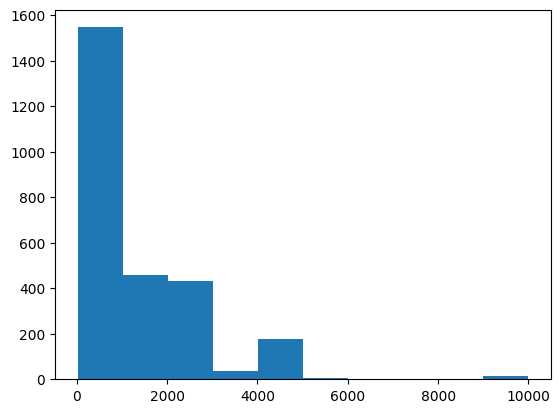

In [167]:
import matplotlib.pyplot as plt
plt.hist(df_master["TRANSACTION_AMT"], bins=10)

In [10]:
PATH = "E:/dime_contributors_1979_2024.csv"
PATH1 = "E:/contrib2024.parquet"

In [11]:
df = pl.scan_csv(PATH, encoding = "utf8-lossy",
                 schema_overrides= {"bonica.cid": pl.Utf8})
contrib = pl.scan_parquet(PATH1)

In [137]:
df.filter(
    (pl.col("most.recent.contributor.name").str.to_lowercase() == "knupp, william") #& 
    #(pl.col("most.recent.contributor.employer").str.contains("visa"))
).collect()

bonica.cid,contributor.type,num.distinct,most.recent.contributor.name,most.recent.contributor.address,most.recent.contributor.city,most.recent.contributor.zipcode,most.recent.contributor.state,most.recent.contributor.latitude,most.recent.contributor.longitude,most.recent.contributor.occupation,most.recent.contributor.employer,most.recent.transaction.id,most.recent.transaction.date,contributor.gender,is.corp,contributor.cfscore,is.projected,first_cycle_active,last_cycle_active,amount.1980,amount.1982,amount.1984,amount.1986,amount.1988,amount.1990,amount.1992,amount.1994,amount.1996,amount.1998,amount.2000,amount.2002,amount.2004,amount.2006,amount.2008,amount.2010,amount.2012,amount.2014,amount.2016,amount.2018,amount.2020,amount.2022,amount.2024
str,str,i64,str,str,str,i64,str,f64,f64,str,str,str,str,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""4146360916""","""I""",4,"""knupp, william""","""one metro center blvd""","""foster city""",94404,"""CA""",37.556,-122.267677,"""product innovation""","""visa usa""","""indv:2008:398787""","""2007-03-13""","""M""",null,0.125,0,2012,2012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2750,0,0,0,0,0,0


In [138]:
ind_data = contrib.filter(
    pl.col("bonica.cid").str.to_lowercase() == "4146360916"
).collect()

In [142]:
ind_data = ind_data.with_columns(pl.col("amount").cast(pl.Float64))
ind_data = ind_data.with_columns(
    pl.col("date")
    .str.strptime(pl.Date, format="%Y-%m-%d", strict=False)
    .alias("date")
)

In [143]:
ind_data

cycle,transaction.id,transaction.type,amount,date,bonica.cid,contributor.name,contributor.lname,contributor.fname,contributor.mname,contributor.suffix,contributor.title,contributor.ffname,contributor.type,contributor.gender,contributor.address,contributor.city,contributor.state,contributor.zipcode,contributor.occupation,contributor.employer,occ.standardized,is.corp,recipient.name,bonica.rid,recipient.party,recipient.type,recipient.state,seat,election.type,latitude,longitude,gis.confidence,contributor.district,censustract,efec.memo,efec.memo2,efec.transaction.id.orig,bk.ref.transaction.id,efec.org.orig,efec.comid.orig,efec.form.type,excluded.from.scaling,contributor.cfscore,candidate.cfscore
str,str,str,f64,date,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""2024""","""e:ind:2024:2024072623:89241825…","""15""",5000.0,2023-01-26,"""4146360916""","""knupp, william""","""knupp""","""william""",null,null,"""mr""","""william""","""I""","""M""","""900 metro center blvd""","""foster city""","""CA""","""944042172""","""svp, gbl interchange & pricing""","""visa usa inc""",null,null,"""VISA, INC. POLITICAL ACTION CO…","""comm19720""",null,"""COMM""","""DC""","""federal:committee""",null,"""37.430676""","""-121.899506""","""0.006""","""CA17""","""06085504504""",null,"""\N""","""AA38A6BE344BC42E284C""",null,"""Visa, Inc. Political Action Co…","""C00365122""","""sa11ai""","""0""","""0.125""",null
"""2024""","""e:ind:2024:2024072717:95714584…","""15""",5000.0,2024-01-29,"""4146360916""","""knupp, william""","""knupp""","""william""",null,null,"""mr""","""william""","""I""","""M""","""900 metro center blvd""","""foster city""","""CA""","""944042172""","""svp, gbl interchange & pricing""","""visa usa inc""",null,null,"""VISA, INC. POLITICAL ACTION CO…","""comm19720""",null,"""COMM""","""DC""","""federal:committee""",null,"""37.430676""","""-121.899506""","""0.006""","""CA17""","""06085504504""",null,"""\N""","""A057A872DBEFA48FBBC8""",null,"""Visa, Inc. Political Action Co…","""C00365122""","""sa11ai""","""0""","""0.125""",null


In [121]:
linda_data.sort("date").write_csv("E:/sample.csv")

In [13]:
# contrib = contrib.select(
#     ["cycle", "amount", "bonica.cid", "date", "contributor.name",
#      "contributor.lname", "contributor.fname", "contributor.mname",
#      "contributor.type", "contributor.gender", "contributor.address",
#      "contributor.city", "contributor.state", "contributor.zipcode",
#      "contributor.occupation", "contributor.employer", "seat",
#      "occ.standardized", "efec.org.orig", "efec.comid.orig"]
# )
result = contrib.filter(
    pl.col("efec.org.orig").is_not_null()
).collect(engine = "streaming")

: 

In [4]:
contrib.head(10).collect()

cycle,transaction.id,transaction.type,amount,date,bonica.cid,contributor.name,contributor.lname,contributor.fname,contributor.mname,contributor.suffix,contributor.title,contributor.ffname,contributor.type,contributor.gender,contributor.address,contributor.city,contributor.state,contributor.zipcode,contributor.occupation,contributor.employer,occ.standardized,is.corp,recipient.name,bonica.rid,recipient.party,recipient.type,recipient.state,seat,election.type,latitude,longitude,gis.confidence,contributor.district,censustract,efec.memo,efec.memo2,efec.transaction.id.orig,bk.ref.transaction.id,efec.org.orig,efec.comid.orig,efec.form.type,excluded.from.scaling,contributor.cfscore,candidate.cfscore
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""2024""","""oh_5907d9432b600fe4ecb4f468462…","""15S""","""140""","""2023-11-22""","""104083862""","""greater stark county afl cio c…",null,null,null,null,null,null,"""C""","""U""","""618 high ave nw""","""canton""","""OH""","""44703""",null,null,null,"""union""","""olson, martin""","""cand95071""","""100""","""CAND""","""OH""","""state:lower""",null,"""40.803326""","""-81.379089""","""0.78""","""OH07""","""39151701700""","""31-e fr contributions""",null,null,null,null,null,null,"""0""","""-0.911""","""-0.74"""
"""2024""","""id_810cfd6ecc5fa244e555ae4cd56…","""24Z""","""15""","""2023-02-25""","""5000002667852691""","""brown, sally boyton""","""brown""","""sally""","""boyton""",null,null,null,"""I""","""F""","""911 w hays st""","""boise""","""ID""","""83702""",null,null,null,null,"""idaho state democratic party""","""comm7197""","""100""","""COMM""","""ID""","""state:committee""",null,"""43.621574""","""-116.199646""","""1""","""ID02""","""16001000100""",null,"""\N""",null,null,null,null,null,"""0""","""-0.847""","""-0.999"""
"""2024""","""e:ind:2024:2024072617:88694332…","""15""","""250""","""2020-09-25""","""32373199050""","""effres, justin""","""effres""","""justin""",null,null,null,"""justin""","""I""","""M""","""4384 saltillo st""","""woodland hills""","""CA""","""91364""","""lawyer""","""effres & associates""","""attorney""",null,"""STAND FOR BETTER PAC""","""comm154842""",null,"""COMM""","""CA""","""federal:committee""",null,"""34.149197""","""-118.594543""","""1""","""CA32""","""06037138000""",null,"""Donation Via Act Blue""","""SA11AI.4105""",null,"""Stand For Better LLC""","""C00758672""","""sa11ai""","""0""","""-0.951""","""-1.122"""
"""2024""","""e:comm:2024:2024072621:8868868…","""24E""","""4600""","""2023-01-01""","""35617273333""","""elbert guillorys america""",null,null,null,null,null,null,"""C""",null,"""228 s washington st14 fl""","""alexandria""","""VA""","""22314""",null,null,null,null,"""BENJAMIN, LEON MR. SR.""","""cand153862""","""200""","""CAND""","""VA""","""federal:house""","""G""","""38.804840""","""-77.046921""","""0.006""","""VA08""","""51510201900""","""Media Placement""",null,"""E0726603FBC9944D5ADA""",null,"""FRIENDS OF LEON BENJAMIN, INC.""","""C00733485""","""24e""","""0""","""1.502""","""1.441"""
"""2024""","""e:comm:2024:2024072621:8868871…","""24A""","""33.58""","""2022-12-06""","""103777006""","""moveonorg political action""",null,null,null,null,null,null,"""C""",null,"""po box 96142""","""washington""","""DC""","""20090""",null,null,null,null,"""TRUMP, DONALD J.""","""cand100270""","""200""","""CAND""","""00""","""federal:president""","""P""","""38.826519""","""-77.017120""","""0.006""","""DC01""","""11001009807""","""Online Ads""",null,"""500041332""",null,"""DONALD J. TRUMP FOR PRESIDENT …","""C00828541""","""24a""","""0""","""-0.962""",null
"""2024""","""e:comm:2024:2024072621:8868891…","""15""","""4866.41""","""2022-11-30""","""35695132347""","""league of conservation voters,…",null,null,null,null,null,null,"""C""",null,"""740 15th st nwfl 7""","""washington""","""DC""","""200051048""",null,null,null,null,"""GIVEGREEN UNI

In [6]:
data_cand = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_candidate_contributions.parquet")
data_principal = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_principal_committee_contributions.parquet")
data_committee = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_committee_contributions.parquet")

In [8]:
data_leadership = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_leadership_pac_contributions.parquet")

In [13]:
data_committee_to_committee = pl.read_parquet("S:/campaignfinance/data/processed/fec/committee_to_committee_contributions.parquet")

In [34]:
data_committee_to_committee.group_by("transaction_type").len().sort("len")

transaction_type,len
str,u32
"""24H""",2
"""40Z""",6
"""41Z""",11
"""42Z""",11
"""22H""",12
…,…
"""24A""",304073
"""18K""",517885
"""24E""",526239


In [35]:
data_committee_to_committee.filter(pl.col("transaction_type") == "15J")

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64
"""C00320051""","""15J""","""P""","""N""","""DARLING, DENNIS A""","""MANAKIN SABOT""","""VA""","""23103""",636.0,null,null,2003,5,20
"""C00320051""","""15J""","""G""","""N""","""HARLOW, BRYCE L""","""MCLEAN""","""VA""","""22101""",1000.0,null,null,2003,5,16
"""C00320051""","""15J""","""P""","""N""","""KOROLOGOS, TOM C""","""WASHINGTON""","""DC""","""20006""",1000.0,null,null,2003,5,13
"""C00265389""","""15J""","""P""","""A""","""DAVIS, THOMAS A""","""WASHINGTON""","""DC""","""20004""",1000.0,null,null,2003,6,20
"""C00265389""","""15J""","""G""","""A""","""HARLOW, BRYCE L""","""MCLEAN""","""VA""","""22101""",1000.0,null,null,2003,5,16
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C00160937""","""15J""","""P""","""A""","""HAGEN, THOMAS B.""","""ERIE""","""PA""","""16514""",1047.0,null,"""* BIDEN VICTORY FUND""",2023,12,13
"""C00160937""","""15J""","""P""","""A""","""HORN, CINDY H.""","""LOS ANGELES""","""CA""","""90077""",42.0,null,"""* BIDEN VICTORY FUND""",2023,12,18
"""C00771394""","""15J""","""G2024""","""A""","""JOHNSON, CHARLES B.""","""PALM BEACH""","""FL""","""33480""",3300.0,null,null,2023,12,13


In [36]:
data_committee_to_committee.filter(pl.col("transaction_type") == "24K")

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64
"""C00379735""","""24K""","""P""","""A""","""BEAUPREZ FOR CONGRESS (CO/H07…","""WHEAT RIDGE""","""CO""","""80034""",1000.0,"""C00376152""",null,2003,2,16
"""C00219865""","""24K""","""P""","""N""",null,null,null,"""<NA>""",2000.0,"""C00279901""",null,2003,1,30
"""C00219865""","""24K""","""G""","""N""",null,null,null,"""<NA>""",2000.0,"""C00279901""",null,2003,1,30
"""C00219865""","""24K""","""P""","""N""",null,null,null,"""<NA>""",1000.0,"""C00358895""",null,2003,2,7
"""C00219865""","""24K""","""P""","""N""",null,null,null,"""<NA>""",2000.0,"""C00346312""",null,2003,2,28
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C00332296""","""24K""","""P2024""","""A""","""TIM SHEEHY FOR MONTANA""","""HELENA""","""MT""","""59604""",30.0,"""C00844159""",null,2024,5,9
"""C00332296""","""24K""","""P2024""","""A""","""TIM SHEEHY FOR MONTANA""","""HELENA""","""MT""","""59604""",30.0,"""C00844159""",null,2024,5,9
"""C00332296""","""24K""","""P2024""","""A""","""TIM SHEEHY FOR MONTANA""","""HELENA""","""MT""","""59604""",30.0,"""C00844159""",null,2024,5,9


In [22]:
sample = data_committee_to_committee.filter(pl.col("transaction_type") == "24K").sample(50)

In [24]:
sample.write_parquet("S:/campaignfinance/data/processed/fec/committee_to_committee_contributions_sample.parquet")

In [9]:
print(data_cand.shape)
print(data_principal.shape)
print(data_committee.shape)
print(data_leadership.shape)

(1118335, 66)
(1109269, 67)
(1372499, 65)
(59832, 67)


In [11]:
1109269/11/1200

84.03553030303031

In [45]:
data_principal.filter(pl.col("cand_id") == "S2CO00175")

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index,cand_id,cmte_type
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str


In [26]:
data_committee_sample = data_committee.sample(50)

In [39]:
data_committee.shape

(1372499, 65)

In [40]:
data_principal.head()

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index,cand_id,cmte_type
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1500.0,"""C00352849""",null,2003,3,5,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Engineering']""","""['Construction & Engineering (…","""['541330']""","""['Professional, Scientific, an…","""['Professional, Scientific, an…","""['Architectural, Engineering, …","""['Engineering Services']""","""['Engineering Services']""",null,"""H0FL04066""","""P"""
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1000.0,"""C00326140""",null,2003,3,7,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Engineering']""","""['Construction & Engineering (…","""['541330']""","""['Professional, Scientific, an…","""['Professional, Scientific, an…","""['Architectural, Engineering, …","""['Engineering Services']""","""['Engineering Services']""",null,"""H4RI01034""","""P"""
"""C00368811""","""24K""","""P""","""N""","""BROWNBACK FOR U.S. SENATE""","""ARLINGTON""","""VA""","""22202""",1000.0,"""C00320051""",null,2003,1,28,2004,"""cingular wireless employee""","""cingular wireless""","""CINGULAR WIRELESS""",null,null,579480.6,"""4295900939""","""00209A106""","""US00209A1060""","""New Cingular Wireless Services…","""New Cingular Wireless Services…","""AWE.N^J04""","""AT&T Wireless Services Inc""",null,"""United States of America""","""WASHINGTON""","""Redmond""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""7/7/1987""",null,null,"""10/27/2004""",null,null,"""Delisted""","""['5740102010', '5740102050', '…","""['Technology', 'Technology', '…","""['Telecommunications Services'…","""['Telecommunications Services'…","""['Wireless Telecommunications …","""['Wireless Telecommunications …","""['517112']""","""['Information']""","""['Telecommunications']""","""['Wired and Wireless Telecommu…","""['Wired and Wireless Telecommu…","""['Wireless Telecommunicat

In [4]:
data_cand

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,cand_id,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index
str,str,str,str,str,str,str,str,f64,str,str,str,i64,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1500.0,"""C00352849""","""H0FL04066""",null,2003,3,5,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Engineering']""","""['Construction & Engineering (…","""['541330']""","""['Professional, Scientific, an…","""['Professional, Scientific, an…","""['Architectural, Engineering, …","""['Engineering Services']""","""['Engineering Services']""",null
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1000.0,"""C00326140""","""H4RI01034""",null,2003,3,7,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Engineering']""","""['Construction & Engineering (…","""['541330']""","""['Professional, Scientific, an…","""['Professional, Scientific, an…","""['Architectural, Engineering, …","""['Engineering Services']""","""['Engineering Services']""",null
"""C00368811""","""24K""","""P""","""N""","""BROWNBACK FOR U.S. SENATE""","""ARLINGTON""","""VA""","""22202""",1000.0,"""C00320051""","""S6KS00122""",null,2003,1,28,2004,"""cingular wireless employee""","""cingular wireless""","""CINGULAR WIRELESS""",null,null,579480.6,"""4295900939""","""00209A106""","""US00209A1060""","""New Cingular Wireless Services…","""New Cingular Wireless Services…","""AWE.N^J04""","""AT&T Wireless Services Inc""",null,"""United States of America""","""WASHINGTON""","""Redmond""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""7/7/1987""",null,null,"""10/27/2004""",null,null,"""Delisted""","""['5740102010', '5740102050', '…","""['Technology', 'Technology', '…","""['Telecommunications Services'…","""['Telecommunications Services'…","""['Wireless Telecommunications …","""['Wireless Telecommunications …","""['517112']""","""['Information']""","""['Telecommunications']""","""['Wired and Wireless Telecommu…","""['Wired and Wireless Telecommu…","""['Wireless Telecommunications …",null
"

In [46]:
pl.read_csv("S:/campaignfinance/data/processed/fec/senate_candidate_principal_committees.csv").head()

committee_id,committee_type,committee_type_full,cycle,designation,designation_full,is_active,name,organization_type,organization_type_full,party,party_full,state,candidate_id,candidate_ids,joint_committee_id,joint_committee_name
str,str,str,i64,str,str,bool,str,str,str,str,str,str,str,str,str,str
"""C00678300""","""S""","""Senate""",2020,"""P""","""Principal campaign committee""",false,"""TIM AALDERS FOR US SENATE""",null,null,"""CON""","""CONSTITUTION PARTY""","""UT""","""S2UT00229""","""S2UT00229""",null,null
"""C00678300""","""S""","""Senate""",2018,"""P""","""Principal campaign committee""",true,"""TIM AALDERS FOR US SENATE""",null,null,"""CON""","""CONSTITUTION PARTY""","""UT""","""S2UT00229""","""S2UT00229""",null,null
"""C00512632""","""S""","""Senate""",2016,"""P""","""Principal campaign committee""",false,"""TIM AALDERS FOR SENATE""",null,null,"""REP""","""REPUBLICAN PARTY""","""UT""","""S2UT00229""","""S2UT00229""",null,null
"""C00512632""","""S""","""Senate""",2014,"""P""","""Principal campaign committee""",true,"""TIM AALDERS FOR SENATE""",null,null,"""REP""","""REPUBLICAN PARTY""","""UT""","""S2UT00229""","""S2UT00229""",null,null
"""C00512632""","""S""","""Senate""",2012,"""P""","""Principal campaign committee""",true,"""TIM AALDERS FOR SENATE""",null,null,"""REP""","""REPUBLICAN PARTY""","""UT""","""S2UT00229""","""S2UT00229""",null,null


In [1]:
from __future__ import annotations

import argparse
import math
from datetime import date, timedelta
from pathlib import Path
from typing import Iterable

import polars as pl

REQUIRED_CONTRIBUTION_COLUMNS = {
    "cmte_id",
    "cand_id",
    "amount",
    "year",
    "month",
    "day",
    "cycle",
}
REQUIRED_EVENT_COLUMNS = {"scandal_id", "cand_id", "event_date", "event_label"}

FIRM_METADATA_COLUMNS = [
    "cmte_nm",
    "connected_org_nm",
    "corporation",
    "parent",
    "website",
    "ttl_receipts",
    "instrument",
    "cusip",
    "isin",
    "common_name",
    "business_description",
    "ric",
    "former_name",
    "business_name",
    "hq",
    "hq_state",
    "hq_city",
    "permid",
    "parent_hq",
    "parent_permid",
    "GICS_ID",
    "GICS_Sector",
    "GICS_Industry_Group",
    "GICS_Industry",
    "GIS_Subindustry",
    "ICB_ID",
    "ICB_Industry",
    "ICB_Super_Sector",
    "ICB_Sector",
    "ICB_Sub_Sector",
    "TRBC_ID",
    "TRBC_Econ_Sector",
    "TRBC_Business_Sector",
    "TRBC_Industry_Group",
    "TRBC_Industry",
    "TRBC_Activity",
    "NAICS_ID",
    "NAICS_Sector",
    "NAICS_Subsector",
    "NAICS_Industry_Group",
    "NAICS_International_Industry",
    "NAICS_National_Industry",
]

PERIOD_KEY_COLUMNS = [
    "scandal_id",
    "period_unit",
    "period_length",
    "relative_period",
    "period_start",
    "period_end",
]

RELATIONSHIP_OUTCOME_COLUMNS = [
    "total_amount",
    "positive_amount",
    "refund_amount",
    "contribution_count",
    "positive_contribution_count",
]

FIRM_OUTCOME_COLUMNS = [
    "total_amount_all_candidates",
    "positive_amount_all_candidates",
    "contribution_count_all_candidates",
    "unique_candidates_all",
    "total_amount_excluding_scandal_cand",
    "positive_amount_excluding_scandal_cand",
    "contribution_count_excluding_scandal_cand",
    "unique_candidates_excluding_scandal_cand",
    "total_amount_to_scandal_cand",
    "positive_amount_to_scandal_cand",
    "contribution_count_to_scandal_cand",
]


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Build tainted-access firm-candidate and firm-period DiD panels."
    )
    parser.add_argument(
        "--contributions",
        type=Path,
        default=DEFAULT_CONTRIBUTIONS_PATH,
        help="Firm PAC to principal committee contribution parquet.",
    )
    parser.add_argument(
        "--events",
        type=Path,
        default=DEFAULT_EVENTS_PATH,
        help="Curated event CSV with scandal_id, cand_id, event_date, event_label.",
    )
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=DEFAULT_OUTPUT_DIR,
        help="Directory for generated panel parquet files.",
    )
    parser.add_argument(
        "--period-unit",
        choices=["quarter", "month"],
        default="quarter",
        help="Base event-time unit.",
    )
    parser.add_argument(
        "--window-pre",
        type=int,
        default=8,
        help="Number of base periods before the event period.",
    )
    parser.add_argument(
        "--window-post",
        type=int,
        default=8,
        help="Number of base periods after and including the event period.",
    )
    parser.add_argument(
        "--period-lengths",
        type=int,
        nargs="+",
        default=[1, 2, 4],
        help="Aggregation lengths in base period units.",
    )
    parser.add_argument(
        "--max-events",
        type=int,
        default=None,
        help="Optional development limit on number of events processed.",
    )
    parser.add_argument(
        "--overwrite",
        action="store_true",
        help="Overwrite existing panel outputs.",
    )
    return parser.parse_args()


def validate_columns(columns: Iterable[str], required: set[str], source: Path) -> None:
    missing = sorted(required - set(columns))
    if missing:
        raise ValueError(f"{source} is missing required columns: {missing}")


def add_months(value: date, months: int) -> date:
    month_index = value.month - 1 + months
    year = value.year + month_index // 12
    month = month_index % 12 + 1
    return date(year, month, 1)


def base_period_start(value: date, period_unit: str) -> date:
    if period_unit == "month":
        return date(value.year, value.month, 1)
    quarter_start_month = ((value.month - 1) // 3) * 3 + 1
    return date(value.year, quarter_start_month, 1)


def base_months(period_unit: str) -> int:
    return 1 if period_unit == "month" else 3


def existing_output_paths(output_dir: Path) -> list[Path]:
    return [
        output_dir / RELATIONSHIP_OUTPUT,
        output_dir / FIRM_OUTPUT,
    ]


def check_outputs(output_dir: Path, overwrite: bool) -> None:
    existing = [path for path in existing_output_paths(output_dir) if path.exists()]
    if existing and not overwrite:
        paths = ", ".join(str(path) for path in existing)
        raise FileExistsError(f"Output already exists. Use --overwrite: {paths}")


def load_events(path: Path, max_events: int | None) -> pl.DataFrame:
    events = pl.read_csv(path, infer_schema_length=10000)
    validate_columns(events.columns, REQUIRED_EVENT_COLUMNS, path)

    events = (
        events.rename({"cand_id": "scandal_cand_id"})
        .with_columns(
            pl.col("scandal_id").cast(pl.Utf8),
            pl.col("scandal_cand_id").cast(pl.Utf8),
            pl.col("event_label").cast(pl.Utf8),
            pl.col("event_date").str.strptime(pl.Date, strict=False),
        )
        .drop_nulls(subset=["scandal_id", "scandal_cand_id", "event_date"])
    )

    for column in ["retirement_date", "resignation_date"]:
        if column in events.columns and events.schema[column] == pl.Utf8:
            events = events.with_columns(
                pl.col(column).str.strptime(pl.Date, strict=False)
            )

    if max_events is not None:
        events = events.head(max_events)
    if events.is_empty():
        raise ValueError(f"No valid events found in {path}")
    return events


def load_contributions(path: Path) -> pl.DataFrame:
    contributions = pl.read_parquet(path)
    validate_columns(contributions.columns, REQUIRED_CONTRIBUTION_COLUMNS, path)

    return contributions.with_columns(
        pl.date(
            pl.col("year").cast(pl.Int32),
            pl.col("month").cast(pl.Int8),
            pl.col("day").cast(pl.Int8),
        ).alias("transaction_date"),
        pl.col("cmte_id").cast(pl.Utf8),
        pl.col("cand_id").cast(pl.Utf8),
    )


def first_non_null(column: str) -> pl.Expr:
    return pl.col(column).drop_nulls().first().alias(column)


def firm_metadata(contributions: pl.DataFrame) -> pl.DataFrame:
    metadata_columns = [
        column for column in FIRM_METADATA_COLUMNS if column in contributions.columns
    ]
    if not metadata_columns:
        return contributions.select("cmte_id").unique()

    return (
        contributions.group_by("cmte_id")
        .agg([first_non_null(column) for column in metadata_columns])
        .sort("cmte_id")
    )


def event_periods(
    event: dict[str, object],
    period_unit: str,
    window_pre: int,
    window_post: int,
    period_lengths: list[int],
) -> pl.DataFrame:
    event_date = event["event_date"]
    if not isinstance(event_date, date):
        raise TypeError("event_date must be parsed as a date")

    anchor = base_period_start(event_date, period_unit)
    base_period_months = base_months(period_unit)
    rows: list[dict[str, object]] = []

    for period_length in period_lengths:
        if period_length <= 0:
            raise ValueError("All --period-lengths values must be positive integers")

        step_months = base_period_months * period_length
        pre_bins = math.ceil(window_pre / period_length)
        post_bins = math.ceil(window_post / period_length)

        for relative_period in range(-pre_bins, post_bins):
            period_start = add_months(anchor, relative_period * step_months)
            period_end = add_months(period_start, step_months) - timedelta(days=1)
            row = dict(event)
            row.update(
                {
                    "period_unit": period_unit,
                    "period_length": period_length,
                    "relative_period": relative_period,
                    "period_start": period_start,
                    "period_end": period_end,
                    "post": int(relative_period >= 0),
                }
            )
            rows.append(row)

    return pl.DataFrame(rows)


def periodized_contributions(
    contributions: pl.DataFrame,
    periods: pl.DataFrame,
) -> pl.DataFrame:
    period_lookup = periods.select(PERIOD_KEY_COLUMNS).unique()
    return (
        contributions.join(period_lookup, how="cross")
        .filter(
            (pl.col("transaction_date") >= pl.col("period_start"))
            & (pl.col("transaction_date") <= pl.col("period_end"))
        )
    )


def relationship_outcomes(periodized: pl.DataFrame) -> pl.DataFrame:
    return periodized.group_by(["cmte_id", "cand_id", *PERIOD_KEY_COLUMNS]).agg(
        pl.col("amount").sum().alias("total_amount"),
        pl.when(pl.col("amount") > 0)
        .then(pl.col("amount"))
        .otherwise(0)
        .sum()
        .alias("positive_amount"),
        pl.when(pl.col("amount") < 0)
        .then(-pl.col("amount"))
        .otherwise(0)
        .sum()
        .alias("refund_amount"),
        pl.len().alias("contribution_count"),
        (pl.col("amount") > 0).sum().alias("positive_contribution_count"),
    )


def firm_outcomes(
    periodized: pl.DataFrame,
    scandal_cand_id: str,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    all_candidates = periodized.group_by(["cmte_id", *PERIOD_KEY_COLUMNS]).agg(
        pl.col("amount").sum().alias("total_amount_all_candidates"),
        pl.when(pl.col("amount") > 0)
        .then(pl.col("amount"))
        .otherwise(0)
        .sum()
        .alias("positive_amount_all_candidates"),
        pl.len().alias("contribution_count_all_candidates"),
        pl.col("cand_id").n_unique().alias("unique_candidates_all"),
    )

    excluding_scandal = (
        periodized.filter(pl.col("cand_id") != scandal_cand_id)
        .group_by(["cmte_id", *PERIOD_KEY_COLUMNS])
        .agg(
            pl.col("amount").sum().alias("total_amount_excluding_scandal_cand"),
            pl.when(pl.col("amount") > 0)
            .then(pl.col("amount"))
            .otherwise(0)
            .sum()
            .alias("positive_amount_excluding_scandal_cand"),
            pl.len().alias("contribution_count_excluding_scandal_cand"),
            pl.col("cand_id").n_unique().alias("unique_candidates_excluding_scandal_cand"),
        )
    )

    scandal_candidate = (
        periodized.filter(pl.col("cand_id") == scandal_cand_id)
        .group_by(["cmte_id", *PERIOD_KEY_COLUMNS])
        .agg(
            pl.col("amount").sum().alias("total_amount_to_scandal_cand"),
            pl.when(pl.col("amount") > 0)
            .then(pl.col("amount"))
            .otherwise(0)
            .sum()
            .alias("positive_amount_to_scandal_cand"),
            pl.len().alias("contribution_count_to_scandal_cand"),
        )
    )

    return all_candidates, excluding_scandal, scandal_candidate


def pre_scandal_relationships(
    contributions: pl.DataFrame,
    scandal_cand_id: str,
    event_date: date,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    positive_pre = contributions.filter(
        (pl.col("transaction_date") < event_date) & (pl.col("amount") > 0)
    )

    candidate_pre = positive_pre.group_by(["cmte_id", "cand_id"]).agg(
        pl.col("amount").sum().alias("pre_amount_to_candidate"),
        pl.len().alias("pre_count_to_candidate"),
    )

    scandal_pre = (
        positive_pre.filter(pl.col("cand_id") == scandal_cand_id)
        .group_by("cmte_id")
        .agg(
            pl.col("amount").sum().alias("pre_amount_to_scandal_cand"),
            pl.len().alias("pre_count_to_scandal_cand"),
        )
    )

    firm_pre = positive_pre.group_by("cmte_id").agg(
        pl.col("amount").sum().alias("pre_total_amount_all_candidates"),
        pl.col("cand_id").n_unique().alias("pre_unique_candidates_all"),
    )

    return candidate_pre, scandal_pre, firm_pre


def zero_fill(frame: pl.DataFrame, columns: list[str]) -> pl.DataFrame:
    present_columns = [column for column in columns if column in frame.columns]
    if not present_columns:
        return frame
    return frame.with_columns([pl.col(column).fill_null(0) for column in present_columns])


def build_relationship_panel(
    event_contributions: pl.DataFrame,
    periods: pl.DataFrame,
    firm_info: pl.DataFrame,
    scandal_cand_id: str,
    event_date: date,
) -> pl.DataFrame:
    risk_pairs = event_contributions.select(["cmte_id", "cand_id"]).unique()
    full_panel = risk_pairs.join(periods, how="cross")
    periodized = periodized_contributions(event_contributions, periods)

    candidate_pre, scandal_pre, _ = pre_scandal_relationships(
        event_contributions, scandal_cand_id, event_date
    )
    outcomes = relationship_outcomes(periodized)

    panel = (
        full_panel.join(outcomes, on=["cmte_id", "cand_id", *PERIOD_KEY_COLUMNS], how="left")
        .join(candidate_pre, on=["cmte_id", "cand_id"], how="left")
        .join(scandal_pre, on="cmte_id", how="left")
        .join(firm_info, on="cmte_id", how="left")
    )

    panel = zero_fill(
        panel,
        [
            *RELATIONSHIP_OUTCOME_COLUMNS,
            "pre_amount_to_candidate",
            "pre_count_to_candidate",
            "pre_amount_to_scandal_cand",
            "pre_count_to_scandal_cand",
        ],
    )

    panel = panel.with_columns(
        (pl.col("positive_contribution_count") > 0)
        .cast(pl.Int8)
        .alias("any_contribution"),
        (pl.col("pre_count_to_candidate") > 0)
        .cast(pl.Int8)
        .alias("ever_pre_contributed_to_candidate"),
        (pl.col("pre_count_to_scandal_cand") > 0)
        .cast(pl.Int8)
        .alias("ever_pre_contributed_to_scandal_cand"),
        (pl.col("cand_id") == pl.col("scandal_cand_id"))
        .cast(pl.Int8)
        .alias("scandal_cand"),
    )

    panel = panel.with_columns(
        (
            (pl.col("scandal_cand") == 1)
            & (pl.col("ever_pre_contributed_to_scandal_cand") == 1)
        )
        .cast(pl.Int8)
        .alias("pre_treated_pair")
    )

    return panel.with_columns(
        pl.col("pre_treated_pair").alias("treated_pair"),
        (pl.col("pre_treated_pair") * pl.col("post")).alias("did_treated_post"),
    )


def build_firm_panel(
    event_contributions: pl.DataFrame,
    periods: pl.DataFrame,
    firm_info: pl.DataFrame,
    scandal_cand_id: str,
    event_date: date,
) -> pl.DataFrame:
    risk_firms = event_contributions.select("cmte_id").unique()
    full_panel = risk_firms.join(periods, how="cross")
    periodized = periodized_contributions(event_contributions, periods)

    _, scandal_pre, firm_pre = pre_scandal_relationships(
        event_contributions, scandal_cand_id, event_date
    )
    all_candidates, excluding_scandal, scandal_candidate = firm_outcomes(
        periodized, scandal_cand_id
    )

    panel = (
        full_panel.join(all_candidates, on=["cmte_id", *PERIOD_KEY_COLUMNS], how="left")
        .join(excluding_scandal, on=["cmte_id", *PERIOD_KEY_COLUMNS], how="left")
        .join(scandal_candidate, on=["cmte_id", *PERIOD_KEY_COLUMNS], how="left")
        .join(firm_pre, on="cmte_id", how="left")
        .join(scandal_pre, on="cmte_id", how="left")
        .join(firm_info, on="cmte_id", how="left")
    )

    panel = zero_fill(
        panel,
        [
            *FIRM_OUTCOME_COLUMNS,
            "pre_total_amount_all_candidates",
            "pre_unique_candidates_all",
            "pre_amount_to_scandal_cand",
            "pre_count_to_scandal_cand",
        ],
    )

    panel = panel.rename(
        {"pre_amount_to_scandal_cand": "pre_total_amount_to_scandal_cand"}
    )

    panel = panel.with_columns(
        (pl.col("contribution_count_all_candidates") > 0)
        .cast(pl.Int8)
        .alias("any_contribution_all"),
        (pl.col("contribution_count_excluding_scandal_cand") > 0)
        .cast(pl.Int8)
        .alias("any_contribution_excluding_scandal_cand"),
        (pl.col("contribution_count_to_scandal_cand") > 0)
        .cast(pl.Int8)
        .alias("any_contribution_to_scandal_cand"),
        (pl.col("pre_count_to_scandal_cand") > 0)
        .cast(pl.Int8)
        .alias("exposed_firm"),
    )

    return panel.with_columns(
        pl.col("exposed_firm").alias("pre_exposed_firm"),
        (pl.col("exposed_firm") * pl.col("post")).alias("did_exposed_post"),
    )


def build_panels(
    contributions: pl.DataFrame,
    events: pl.DataFrame,
    period_unit: str,
    window_pre: int,
    window_post: int,
    period_lengths: list[int],
) -> tuple[pl.DataFrame, pl.DataFrame]:
    firm_info = firm_metadata(contributions)
    relationship_panels: list[pl.DataFrame] = []
    firm_panels: list[pl.DataFrame] = []

    for event in events.iter_rows(named=True):
        periods = event_periods(
            event,
            period_unit=period_unit,
            window_pre=window_pre,
            window_post=window_post,
            period_lengths=period_lengths,
        )
        window_start = periods["period_start"].min()
        window_end = periods["period_end"].max()
        scandal_cand_id = str(event["scandal_cand_id"])
        event_date = event["event_date"]

        event_contributions = contributions.filter(
            (pl.col("transaction_date") >= window_start)
            & (pl.col("transaction_date") <= window_end)
        )
        if event_contributions.is_empty():
            continue

        relationship_panels.append(
            build_relationship_panel(
                event_contributions,
                periods,
                firm_info,
                scandal_cand_id,
                event_date,
            )
        )
        firm_panels.append(
            build_firm_panel(
                event_contributions,
                periods,
                firm_info,
                scandal_cand_id,
                event_date,
            )
        )

    if not relationship_panels or not firm_panels:
        raise ValueError("No panel rows were created for the supplied event windows")

    relationship_panel = pl.concat(relationship_panels, how="diagonal_relaxed")
    firm_panel = pl.concat(firm_panels, how="diagonal_relaxed")
    return relationship_panel, firm_panel

In [2]:
contributions = load_contributions("S:/campaignfinance/data/processed/fec/firm_pac_to_principal_committee_contributions.parquet")

In [15]:
events = pl.DataFrame(
    {
        "scandal_id": ["SC001", "SC002"],
        "cand_id": ["H4RI01034", "H0OH06189"],
        "event_date": ["2003-05-01", "2023-04-20"],
        "event_label": ["Scandal 1", "Scandal 2"]
    }
)
events = (
        events.rename({"cand_id": "scandal_cand_id"})
        .with_columns(
            pl.col("scandal_id").cast(pl.Utf8),
            pl.col("scandal_cand_id").cast(pl.Utf8),
            pl.col("event_label").cast(pl.Utf8),
            pl.col("event_date").str.strptime(pl.Date, strict=False),
        )
        .drop_nulls(subset=["scandal_id", "scandal_cand_id", "event_date"])
    )

In [16]:
events.row(0)

('SC001', 'H4RI01034', datetime.date(2003, 5, 1), 'Scandal 1')

In [17]:
event =first_row = events.row(0, named=True)
periods = event_periods(
    event,
    period_unit="month",
    window_pre=8,
    window_post=8,
    period_lengths=[1],
)

In [18]:
firm_info = firm_metadata(contributions)

In [19]:
window_start = periods["period_start"].min()
window_end = periods["period_end"].max()
scandal_cand_id = str(event["scandal_cand_id"])
event_date = event["event_date"]

In [20]:
event_contributions = contributions.filter(
    (pl.col("transaction_date") >= window_start)
     & (pl.col("transaction_date") <= window_end)
)

In [21]:
event_contributions.filter(pl.col("cand_id") == "H4RI01034").head(n=10)

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index,cand_id,cmte_type,transaction_date
str,str,str,str,str,str,str,str,f64,str,str,i64,i64,i64,i64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,date
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1000.0,"""C00326140""",null,2003,3,7,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Engineering']""","""['Construction & Engineering (…","""['541330']""","""['Professional, Scientific, an…","""['Professional, Scientific, an…","""['Architectural, Engineering, …","""['Engineering Services']""","""['Engineering Services']""",null,"""H4RI01034""","""P""",2003-03-07
"""C00316331""","""24K""","""P""","""A""","""FRIENDS OF PATRICK J KENNEDY '…","""PROVIDENCE""","""RI""","""02901""",1000.0,"""C00326140""",null,2003,9,23,2004,"""international game technology""","""international game technology""","""INTERNATIONAL GAME TECHNOLOGY""",null,null,195240.99,"""IGT.N""",null,"""GB00BVG7F061""","""International Game Technology …","""International Game Technology …","""IGT.N""","""Georgia Worldwide Ltd""",null,"""United Kingdom""",null,"""London""",5.0440e9,"""Italy""",4.2985e9,2.530101e7,"""Consumer Discretionary""","""Consumer Services""","""Hotels, Restaurants & Leisure""","""Casinos & Gaming""",4.050102e7,"""Consumer Discretionary""","""Travel and Leisure""","""Travel and Leisure""","""Casinos and Gambling""","""7/11/2014""","""4/7/2015""","""4/7/2015""",null,null,null,"""Listed""","""['5330103010']""","""['Consumer Cyclicals']""","""['Cyclical Consumer Services']""","""['Hotels & Entertainment Servi…","""['Casinos & Gaming']""","""['Casinos & Gaming (NEC)']""","""['713290', '334118', '713210']""","""['Arts, Entertainment, and Rec…","""['Amusement, Gambling, and Rec…","""['Gambling Industries', 'Compu…","""['Other Gambling Industries', …","""['Other Gambling Industries', …",null,"""H4RI01034""","""P""",2003-09-23
"""C00362582""","""24K""","""G""","""N""",null,null,null,"""<NA>""",1000.0,"""C00326140""",null,2003,3,7,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220""","""268057106""","""US2680571062""","""Dynamics Research Corp""","""Dynamics Research Corp is a Un…","""DRCO.OQ^B14""",null,null,"""United States of America""","""OHIO""","""Richfield""",4.2959e9,"""United States""",4.2959e9,null,null,null,null,null,null,null,null,null,null,"""5/27/1955""",null,null,"""2/3/2014""",2017.0,6.0,"""Delisted""","""['5220102010']""","""['Industrials']""","""['Industrial & Commercial Serv…","""['Construction & Engineering']""","""['Construction & Eng

In [53]:
risk_pairs = event_contributions.select(["cmte_id", "cand_id"]).unique()

In [54]:
full_panel = risk_pairs.join(periods, how="cross")

In [55]:
periodized = periodized_contributions(event_contributions, periods)

In [ ]:
candidate_pre, scandal_pre, _ = pre_scandal_relationships(
        event_contributions, scandal_cand_id, event_date
    )

In [58]:
outcomes = relationship_outcomes(periodized)

In [62]:
panel = (
        full_panel.join(outcomes, on=["cmte_id", "cand_id", *PERIOD_KEY_COLUMNS], how="left")
        .join(candidate_pre, on=["cmte_id", "cand_id"], how="left")
        .join(scandal_pre, on="cmte_id", how="left")
        .join(firm_info, on="cmte_id", how="left")
    )

In [65]:
panel

cmte_id,cand_id,scandal_id,scandal_cand_id,event_date,event_label,period_unit,period_length,relative_period,period_start,period_end,post,total_amount,positive_amount,refund_amount,contribution_count,positive_contribution_count,pre_amount_to_candidate,pre_count_to_candidate,pre_amount_to_scandal_cand,pre_count_to_scandal_cand,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry
str,str,str,str,date,str,str,i64,i64,date,date,i64,f64,f64,f64,u32,u32,f64,u32,f64,u32,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""C00034405""","""H2IL10068""","""SC002""","""H0OH06189""",2023-04-20,"""Scandal 2""","""month""",1,-8,2022-08-01,2022-08-31,0,null,null,null,null,null,2000.0,1,null,null,"""international paper""","""international paper""","""International Paper""",null,null,702382.99,"""IP.N""","""460146103""","""US4601461035""","""International Paper Co""","""International Paper Company pr…","""IP.N""","""International Paper and Power …",null,"""United States of America""","""TENNESSEE""","""Memphis""",4.2959e9,"""United States""",4.2959e9,1.510302e7,"""Materials""","""Materials""","""Containers & Packaging""","""Paper & Plastic Packaging Prod…",5.5101015e7,"""Basic Materials""","""Basic Resources""","""Industrial Materials""","""Paper""","""['5130202010']""","""['Basic Materials']""","""['Applied Resources']""","""['Containers & Packaging']""","""['Paper Packaging']""","""['Paper Packaging (NEC)']""","""['322130', '322120', '322211']""","""['Manufacturing', 'Manufacturi…","""['Paper Manufacturing', 'Paper…","""['Pulp, Paper, and Paperboard …","""['Paperboard Mills', 'Paper Mi…","""['Paperboard Mills', 'Paper Mi…"
"""C00034405""","""H2IL10068""","""SC002""","""H0OH06189""",2023-04-20,"""Scandal 2""","""month""",1,-7,2022-09-01,2022-09-30,0,2000.0,2000.0,0.0,1,1,2000.0,1,null,null,"""international paper""","""international paper""","""International Paper""",null,null,702382.99,"""IP.N""","""460146103""","""US4601461035""","""International Paper Co""","""International Paper Company pr…","""IP.N""","""International Paper and Power …",null,"""United States of America""","""TENNESSEE""","""Memphis""",4.2959e9,"""United States""",4.2959e9,1.510302e7,"""Materials""","""Materials""","""Containers & Packaging""","""Paper & Plastic Packaging Prod…",5.5101015e7,"""Basic Materials""","""Basic Resources""","""Industrial Materials""","""Paper""","""['5130202010']""","""['Basic Materials']""","""['Applied Resources']""","""['Containers & Packaging']""","""['Paper Packaging']""","""['Paper Packaging (NEC)']""","""['322130', '322120', '322211']""","""['Manufacturing', 'Manufacturi…","""['Paper Manufacturing', 'Paper…","""['Pulp, Paper, and Paperboard …","""['Paperboard Mills', 'Paper Mi…","""['Paperboard Mills', 'Paper Mi…"
"""C00034405""","""H2IL10068""","""SC002""","""H0OH06189""",2023-04-20,"""Scandal 2""","""month""",1,-6,2022-10-01,2022-10-31,0,null,null,null,null,null,2000.0,1,null,null,"""international paper""","""international paper""","""International Paper""",null,null,702382.99,"""IP.N""","""460146103""","""US4601461035""","""International Paper Co""","""International Paper Company pr…","""IP.N""","""International Paper and Power …",null,"""United States of America""","""TENNESSEE""","""Memphis""",4.2959e9,"""United States""",4.2959e9,1.510302e7,"""Materials""","""Materials""","""Containers & Packaging""","""Paper & Plastic Packaging Prod…",5.510

In [22]:
relationship_panel, firm_panel = build_panels(
        contributions=contributions,
        events=events,
        period_unit="month",
        window_pre=8,
        window_post=8,
        period_lengths=[1],
    )

In [24]:
relationship_panel.filter(pl.col("cand_id") == "H4RI01034").write_csv("E:/relationship_panel_sample.csv")

In [7]:
relationship_panel

cmte_id,cand_id,scandal_id,scandal_cand_id,event_date,event_label,period_unit,period_length,relative_period,period_start,period_end,post,total_amount,positive_amount,refund_amount,contribution_count,positive_contribution_count,pre_amount_to_candidate,pre_count_to_candidate,pre_amount_to_scandal_cand,pre_count_to_scandal_cand,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,any_contribution,ever_pre_contributed_to_candidate,ever_pre_contributed_to_scandal_cand,scandal_cand,pre_treated_pair,treated_pair,did_treated_post
str,str,str,str,date,str,str,i64,i64,date,date,i64,f64,f64,f64,u32,u32,f64,u32,f64,u32,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i8,i8,i8,i8,i8,i8,i64
"""C00327072""","""H2FL14186""","""SC001""","""H4RI01034""",2023-05-01,"""Scandal 1""","""month""",1,-8,2022-09-01,2022-09-30,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0,"""sovereign bancorp""","""sovereign bancorp""","""SOVEREIGN BANCORP""","""SAN.MC""",null,101466.18,"""5000001412""","""80282K205""","""US80282K2050""","""Santander Holdings USA Inc""","""Santander Holdings USA, Inc. i…","""SOV_pc.N^H18""","""Sovereign Merger Corp""",null,"""United States of America""","""MASSACHUSETTS""","""Boston""",5.0000e9,"""Spain""",8.5899e9,4.0101015e7,"""Financials""","""Banks""","""Banks""","""Regional Banks""",null,null,null,null,null,"""['5510101010', '5510101011']""","""['Financials', 'Financials']""","""['Banking & Investment Service…","""['Banking Services', 'Banking …","""['Banks', 'Banks']""","""['Banks (NEC)', 'Corporate Ban…","""['522110', '523150', '522180',…","""['Finance and Insurance', 'Fin…","""['Credit Intermediation and Re…","""['Depository Credit Intermedia…","""['Commercial Banking', 'Invest…","""['Commercial Banking', 'Invest…",0,0,0,0,0,0,0
"""C00327072""","""H2FL14186""","""SC001""","""H4RI01034""",2023-05-01,"""Scandal 1""","""month""",1,-7,2022-10-01,2022-10-31,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0,"""sovereign bancorp""","""sovereign bancorp""","""SOVEREIGN BANCORP""","""SAN.MC""",null,101466.18,"""5000001412""","""80282K205""","""US80282K2050""","""Santander Holdings USA Inc""","""Santander Holdings USA, Inc. i…","""SOV_pc.N^H18""","""Sovereign Merger Corp""",null,"""United States of America""","""MASSACHUSETTS""","""Boston""",5.0000e9,"""Spain""",8.5899e9,4.0101015e7,"""Financials""","""Banks""","""Banks""","""Regional Banks""",null,null,null,null,null,"""['5510101010', '5510101011']""","""['Financials', 'Financials']""","""['Banking & Investment Service…","""['Banking Services', 'Banking …","""['Banks', 'Banks']""","""['Banks (NEC)', 'Corporate Ban…","""['522110', '523150', '522180',…","""['Finance and Insurance', 'Fin…","""['Credit Intermediation and Re…","""['Depository Credit Intermedia…","""['Commercial Banking', 'Invest…","""['Commercial Banking', 'Invest…",0,0,0,0,0,0,0
"""C00327072""","""H2FL14186""","""SC001""","""H4RI01034""",2023-05-01,"""Scandal 1""","""month""",1,-6,2022-11-01,2022-11-30,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0,"""sovereign bancorp""","""sovereign bancorp""","""SOVEREIGN BANCORP""","""SAN.MC""",null,101466.18,"""5000001412""","""80282K205""","""US80282K2050""","""Santander Holdings USA Inc""","""Santander Holdings USA, Inc. i…","""SOV_pc.N^H18""","""Sovereign Merger Corp""",null,"""United States of America""","""MASSACHUSETTS""","""Boston""",5.0000e9,"""Spain""",8.5899e9,4.0101015e7,"""Financials""","""Banks""","""Banks""","""Regional Banks""",n

In [6]:
data = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_candidate_contributions.parquet")


In [7]:
data

cmte_id,transaction_type,election_indicator,amendment,name,city,state,zip,amount,rcpt_cmte,cand_id,memo,year,month,day,cycle,cmte_nm,connected_org_nm,corporation,parent,website,ttl_receipts,instrument,cusip,isin,common_name,business_description,ric,former_name,business_name,hq,hq_state,hq_city,permid,parent_hq,parent_permid,GICS_ID,GICS_Sector,GICS_Industry_Group,GICS_Industry,GIS_Subindustry,ICB_ID,ICB_Industry,ICB_Super_Sector,ICB_Sector,ICB_Sub_Sector,Incorporation_Date,Public_Date,IPO_Date,Retire_Date,Inactive_Year,Inactive_Event,Listing_Status,TRBC_ID,TRBC_Econ_Sector,TRBC_Business_Sector,TRBC_Industry_Group,TRBC_Industry,TRBC_Activity,NAICS_ID,NAICS_Sector,NAICS_Subsector,NAICS_Industry_Group,NAICS_International_Industry,NAICS_National_Industry,index
str,str,str,str,str,str,str,str,f64,str,str,str,i64,i64,i64,i32,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1500.0,"""C00352849""","""H0FL04066""",null,2003,3,5,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220.0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""C00362582""","""24K""",null,"""N""",null,null,null,"""<NA>""",1000.0,"""C00326140""","""H4RI01034""",null,2003,3,7,2004,"""dynamics research""","""dynamics research""","""DYNAMICS RESEARCH""",null,null,29203.38,"""4295906220.0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""C00368811""","""24K""","""P""","""N""","""BROWNBACK FOR U.S. SENATE""","""ARLINGTON""","""VA""","""22202""",1000.0,"""C00320051""","""S6KS00122""",null,2003,1,28,2004,"""cingular wireless employee""","""cingular wireless""","""CINGULAR WIRELESS""",null,null,579480.6,"""4295900939.0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""C00368811""","""24K""","""P""","""N""","""FRIENDS OF BYRON DORGAN""","""WASHINGTON""","""DC""","""20002""",1000.0,"""C00143438""","""S2ND00040""",null,2003,1,7,2004,"""cingular wireless employee""","""cingular wireless""","""CINGULAR WIRELESS""",null,null,579480.6,"""4295900939.0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""C00144774""","""24K""","""P""","""N""","""FRIENDS OF KENT CONRAD""","""BISMARCK""","""ND""","""58502""",-1000.0,"""C00202754""","""S6ND00058""",null,2003,1,24,2004,"""southern employees""","""southern""","""SOUTHERN COMPANY""",null,null,492389.09,"""SO.N""","""842587107""","""US8425871071""","""Southern Co""","""The Southern Company is an ene…","""SO.N""",null,null,"""United States of America""","""GEORGIA""","""Atlanta""",4.2959e9,"""United States""",4.2959e9,5.510101e7,"""Utilities""","""Utilities""","""Electric Utilities""","""Electric Utilities""",6.5101015e7,"""Utilities""","""Utilities""","""Electricity""","""Conventional Electricity""","""11/9/1945""","""9/30/1949""","""9/30/1949""",null,null,null,"""Listed""","""['5910101010']""","""['Utilities']""","""['Utilities']""","""['Electric Utilities & IPPs']""","""['Electric Utilities']""","""['Electric Utilities (NEC)']""","""['221112', '221113', '221111',…","""['Utilities', 'Utilities', 'Ut…","""['Utilities', 'Utilities', 'Ut…","""['Electric Power Generation, T…","""['Electric Power Generation',

In [2]:
data_principal = pl.read_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_principal_committee_contributions.parquet")
house_cand = pl.read_csv("S:/campaignfinance/data/raw/fec_api/candidates/candidate_history_H.csv",
                         schema_overrides={"address_zip": pl.Utf8})
senate_cand = pl.read_csv("S:/campaignfinance/data/raw/fec_api/candidates/candidate_history_S.csv",
                         schema_overrides={"address_zip": pl.Utf8})

In [3]:
def parse_last_name(x):
    suffixes = {"JR", "SR", "II", "III", "IV", "V"}

    before_comma = x.split(",")[0].strip()
    parts = before_comma.split()
    while parts and parts[-1].upper().strip(".") in suffixes:
        parts.pop()
    if not parts:
        return ""
    last = parts[-1].split("-")[-1]
    last_clean = ''.join(c for c in last if c.isalpha())

    return last_clean

house_cand = (
    house_cand
    .drop_nulls(subset = ["candidate_election_year", "district"])
    .with_columns([
        pl.col("candidate_election_year").cast(pl.Int64).alias("year"),
        pl.col("district").cast(pl.Int64),
        pl.col("name").map_elements(parse_last_name, return_dtype=pl.Utf8).alias("last_name")
    ])
    .select([
        "candidate_id",
        "state", 
        "district",
        "year",
        "incumbent_challenge",
        "party",
        "last_name"
    ])
    .rename({"year":"cycle"})
)

senate_cand = (
    senate_cand
    .drop_nulls(subset = ["candidate_election_year", "district"])
    .with_columns([
        pl.col("candidate_election_year").cast(pl.Int64).alias("year"),
        pl.col("district").cast(pl.Int64),
        pl.col("name").map_elements(parse_last_name, return_dtype=pl.Utf8).alias("last_name")
    ])
    .select([
        "candidate_id",
        "state", 
        "district",
        "year",
        "incumbent_challenge",
        "party",
        "last_name"
    ])
    .rename({"year":"cycle"})
)

In [6]:
data_contribute = data_principal.rename(
    {"name": "rcpt_name",
     "city": "rcpt_city",
     "state": "rcpt_state",
     "zip": "rcpt_zip"}
)

In [19]:
data_merged = data_contribute.join(
    house_cand,
    left_on = ["cand_id", "cycle"],
    right_on = ["candidate_id", "cycle"],
    how = "left"
)

In [11]:
def cycle_forward_asof_join(
    A: pl.DataFrame | pl.LazyFrame,
    B: pl.DataFrame | pl.LazyFrame,
    *,
    left_match_cols: str | list[str],
    right_match_cols: str | list[str],
    left_cycle_col: str = "cycle",
    right_cycle_col: str = "cycle",
    tolerance: int = 4,
    suffix: str = "_B",
    keep_right_cycle_col: str = "matched_cycle_B",
    restore_left_order: bool = True,
) -> pl.DataFrame | pl.LazyFrame:
    """
    Left join A to B using exact-match columns plus forward cycle matching.

    Exact match:
        A[left_match_cols[i]] == B[right_match_cols[i]]

    Cycle match:
        B[right_cycle_col] >= A[left_cycle_col]
        B[right_cycle_col] <= A[left_cycle_col] + tolerance

    Among eligible B rows, chooses the lowest B[right_cycle_col].
    """

    if isinstance(left_match_cols, str):
        left_by = [left_match_cols]
    else:
        left_by = list(left_match_cols)

    if isinstance(right_match_cols, str):
        right_by = [right_match_cols]
    else:
        right_by = list(right_match_cols)

    if len(left_by) != len(right_by):
        raise ValueError(
            "`left_match_cols` and `right_match_cols` must have the same length."
        )

    A_work = A
    B_work = B

    if restore_left_order:
        A_work = A_work.with_row_index("_a_row_order")

    # Keep the right-side cycle value, because asof joins usually keep only
    # the left as-of key column in the final result.
    B_work = B_work.with_columns(
        pl.col(right_cycle_col).alias(keep_right_cycle_col)
    )

    # Make sure the cycle columns have compatible numeric types.
    A_work = A_work.with_columns(
        pl.col(left_cycle_col).cast(pl.Int32)
    )

    B_work = B_work.with_columns(
        pl.col(right_cycle_col).cast(pl.Int32)
    )

    # Polars requires sorted inputs for asof joins.
    A_sorted = A_work.sort([*left_by, left_cycle_col])
    B_sorted = B_work.sort([*right_by, right_cycle_col])

    out = A_sorted.join_asof(
        B_sorted,
        left_on=left_cycle_col,
        right_on=right_cycle_col,
        by_left=left_by,
        by_right=right_by,
        strategy="forward",
        tolerance=tolerance,
        suffix=suffix,
    )

    if restore_left_order:
        out = out.sort("_a_row_order").drop("_a_row_order")

    return out

In [14]:
senate_cand

candidate_id,state,district,cycle,incumbent_challenge,party,last_name
str,str,i64,i64,str,str,str
"""S2CO00175""","""CO""",0,2022,"""C""","""REP""","""AADLAND"""
"""S2UT00229""","""UT""",0,2018,"""O""","""CON""","""AALDERS"""
"""S2UT00229""","""UT""",0,2018,"""C""","""REP""","""AALDERS"""
"""S2UT00229""","""UT""",0,2018,"""C""","""REP""","""AALDERS"""
"""S2UT00229""","""UT""",0,2012,"""C""","""REP""","""AALDERS"""
…,…,…,…,…,…,…
"""S8NC00338""","""NC""",0,2028,null,"""REP""","""BROWN"""
"""S0OK00370""","""OK""",0,2020,"""C""","""DEM""","""BROYLES"""
"""S2SC00145""","""SC""",0,2026,"""C""","""DEM""","""BRUCE"""


In [20]:
data_merged = cycle_forward_asof_join(
    A=data_merged,
    B=senate_cand,
    left_match_cols=["cand_id"],
    right_match_cols=["candidate_id"],
    left_cycle_col="cycle",
    right_cycle_col="cycle",
    tolerance=4,
)

C:\Users\zih028\AppData\Local\Temp\ipykernel_21952\1062459444.py:67: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  out = A_sorted.join_asof(


In [21]:
data_merged = data_merged.with_columns(
    pl.col("last_name").fill_null(pl.col("last_name_B")).alias("last_name"),
    pl.col("state").fill_null(pl.col("state_B")).alias("state"),
    pl.col("district").fill_null(pl.col("district_B")).alias("district"),
    pl.col("incumbent_challenge").fill_null(pl.col("incumbent_challenge_B")).alias("incumbent_challenge"),
    pl.col("party").fill_null(pl.col("party_B")).alias("party"),
    pl.col("matched_cycle_B").fill_null(pl.col("cycle")).alias("matched_cycle")
).drop([
    "last_name_B",
    "state_B",
    "district_B",
    "incumbent_challenge_B",
    "party_B",
    "cycle",
    "matched_cycle_B"
]).rename({"matched_cycle": "cycle"})


In [27]:
data_merged.write_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_principal_committee_contributions_with_candidate_info.parquet")

In [28]:
data_merged_sample = data_merged.sample(200)

In [30]:
data_merged_sample.write_parquet("S:/campaignfinance/data/processed/fec/firm_pac_to_principal_committee_contributions_with_candidate_info_sample.parquet")